# CA1 – Data Preparation

Student Name:  Pericles Bispo Matos

Student Number:  2026193

## Introduction

The objective of this study is to process and evaluate a student database, aiming to discover possible trends associated with academic performance. The processes that will be used for this analysis include data cleaning, exploratory data analysis (EDA), and dimensionality reduction through Principal Component Analysis (PCA) to reduce the number of variables, in order to investigate whether this improves data quality and, consequently, the model's performance.

In [147]:
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import norm
import pandas as pd
import seaborn as sns


In [148]:
student_data = pd.read_csv("student_data.csv")

In [149]:
student_data.shape

(4424, 37)

## DATASET CHARACTERISATION

The data has approximately 4415 entries and 37 columns and presents a combination of numerical and categorical data related to student academic performance and history.

After a preliminary analysis, the absence of values ​​in the data was observed; this may affect the reliability of any analysis performed if not properly addressed.

There are three distinct categories in the target variable (dropout, enrolled, and graduated) that represent different types of student academic performance.

In general, the size of the dataset is relatively moderate and therefore appropriate for the application of exploratory techniques or dimensionality reduction methods.

In [150]:
student_data = pd.read_csv("student_data.csv")
student_data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [151]:
print("First 5 rows of the dataset:")
display(student_data.head())

First 5 rows of the dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Data Cleaning:
The first step in preparing a dataset for analysis, data cleaning (or preprocessing), was performed to ensure that the data is accurate and consistent enough for analysis. Missing values ​​were addressed to avoid inconsistent or biased analyses.

Additionally, some of the variable fields were checked and corrected as needed to verify the correct field type and aid in the accuracy of the interpretation.

This step is crucial, as poor-quality data will affect both the ability to analyze the data effectively and the effectiveness of the models created.

In [152]:
print("\nDataset information:")
student_data.info()

print("\nDescriptive statistics:")
display(student_data.describe(include="all"))

print("\nMissing values before cleaning:")
print(student_data.isnull().sum())

print("\nDuplicate rows:", student_data.duplicated().sum())

print("\nTarget values before cleaning:")
print(student_data["Target"].value_counts(dropna=False))


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualificat

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4423.000000,...,4424.000000,4423.000000,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,3918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2207
mean,NaN,18.669078,1.727848,8856.458738,0.890823,4.577758,132.613314,1.873192,19.561935,22.271987,...,0.541817,6.231743,8.063291,4.435805,10.229941,0.150316,11.566139,1.228029,0.001969,NaN
std,NaN,17.484682,1.313793,2063.763479,0.311897,10.216592,13.188332,6.914514,15.603186,15.343244,...,1.918546,2.196038,3.947951,3.014764,5.211367,0.753774,2.663850,1.382711,2.269935,NaN
min,NaN,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,NaN,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,NaN,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,NaN,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN



Missing values before cleaning:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            1
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            1
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   1
Displaced                                         0
Educational special needs                         0
Debtor                                            1
Tuition fees up to date                           1
Gender                                            0
Scholarship holder             

In [153]:
student_data = student_data.replace("?", np.nan)

student_data.columns = (
    student_data.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("'", "", regex=False)
)

print("\nCleaned column names:")
print(student_data.columns)

student_data["Target"] = student_data["Target"].replace({
    "Grad": "Graduate",
    "graduate": "Graduate",
    "Drop": "Dropout",
    "dropout": "Dropout"
})

print("\nTarget values after label cleaning:")
print(student_data["Target"].value_counts(dropna=False))

for col in student_data.columns:
    if col != "Target":
        try:
            student_data[col] = pd.to_numeric(student_data[col])
        except:
            pass

print("\nData types after conversion:")
print(student_data.dtypes)

print("\nMissing values after replacing '?' and converting types:")
print(student_data.isnull().sum())


Cleaned column names:
Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curri

In [154]:


numeric_cols = student_data.select_dtypes(include=np.number).columns
for col in numeric_cols:
    student_data[col] = student_data[col].fillna(student_data[col].median())

categorical_cols = student_data.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    student_data[col] = student_data[col].fillna(student_data[col].mode()[0])

print("\nMissing values after imputation:")
print(student_data.isnull().sum())

print("\nDataset shape after cleaning:", student_data.shape)


Missing values after imputation:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollmen

In [155]:
student_data.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.544982,0.890823,4.577758,132.613314,1.873192,19.561935,22.271248,...,0.137658,0.541817,6.231691,8.063291,4.435805,10.230387,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.538140,0.311897,10.216592,13.188332,6.914514,15.603186,15.341589,...,0.690880,1.918546,2.195793,3.947951,3.014764,5.210862,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


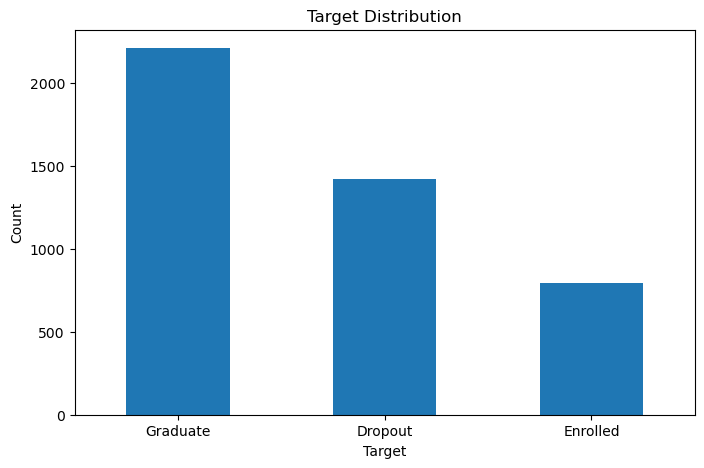

In [156]:

plt.figure(figsize=(8,5))
student_data["Target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [157]:
student_data.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [158]:
student_data["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [159]:
student_data.duplicated().sum()

np.int64(0)

In [160]:
student_data.columns = student_data.columns.str.strip().str.replace(" ", "_")
student_data.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

# Distribution of Variables (Histogram)

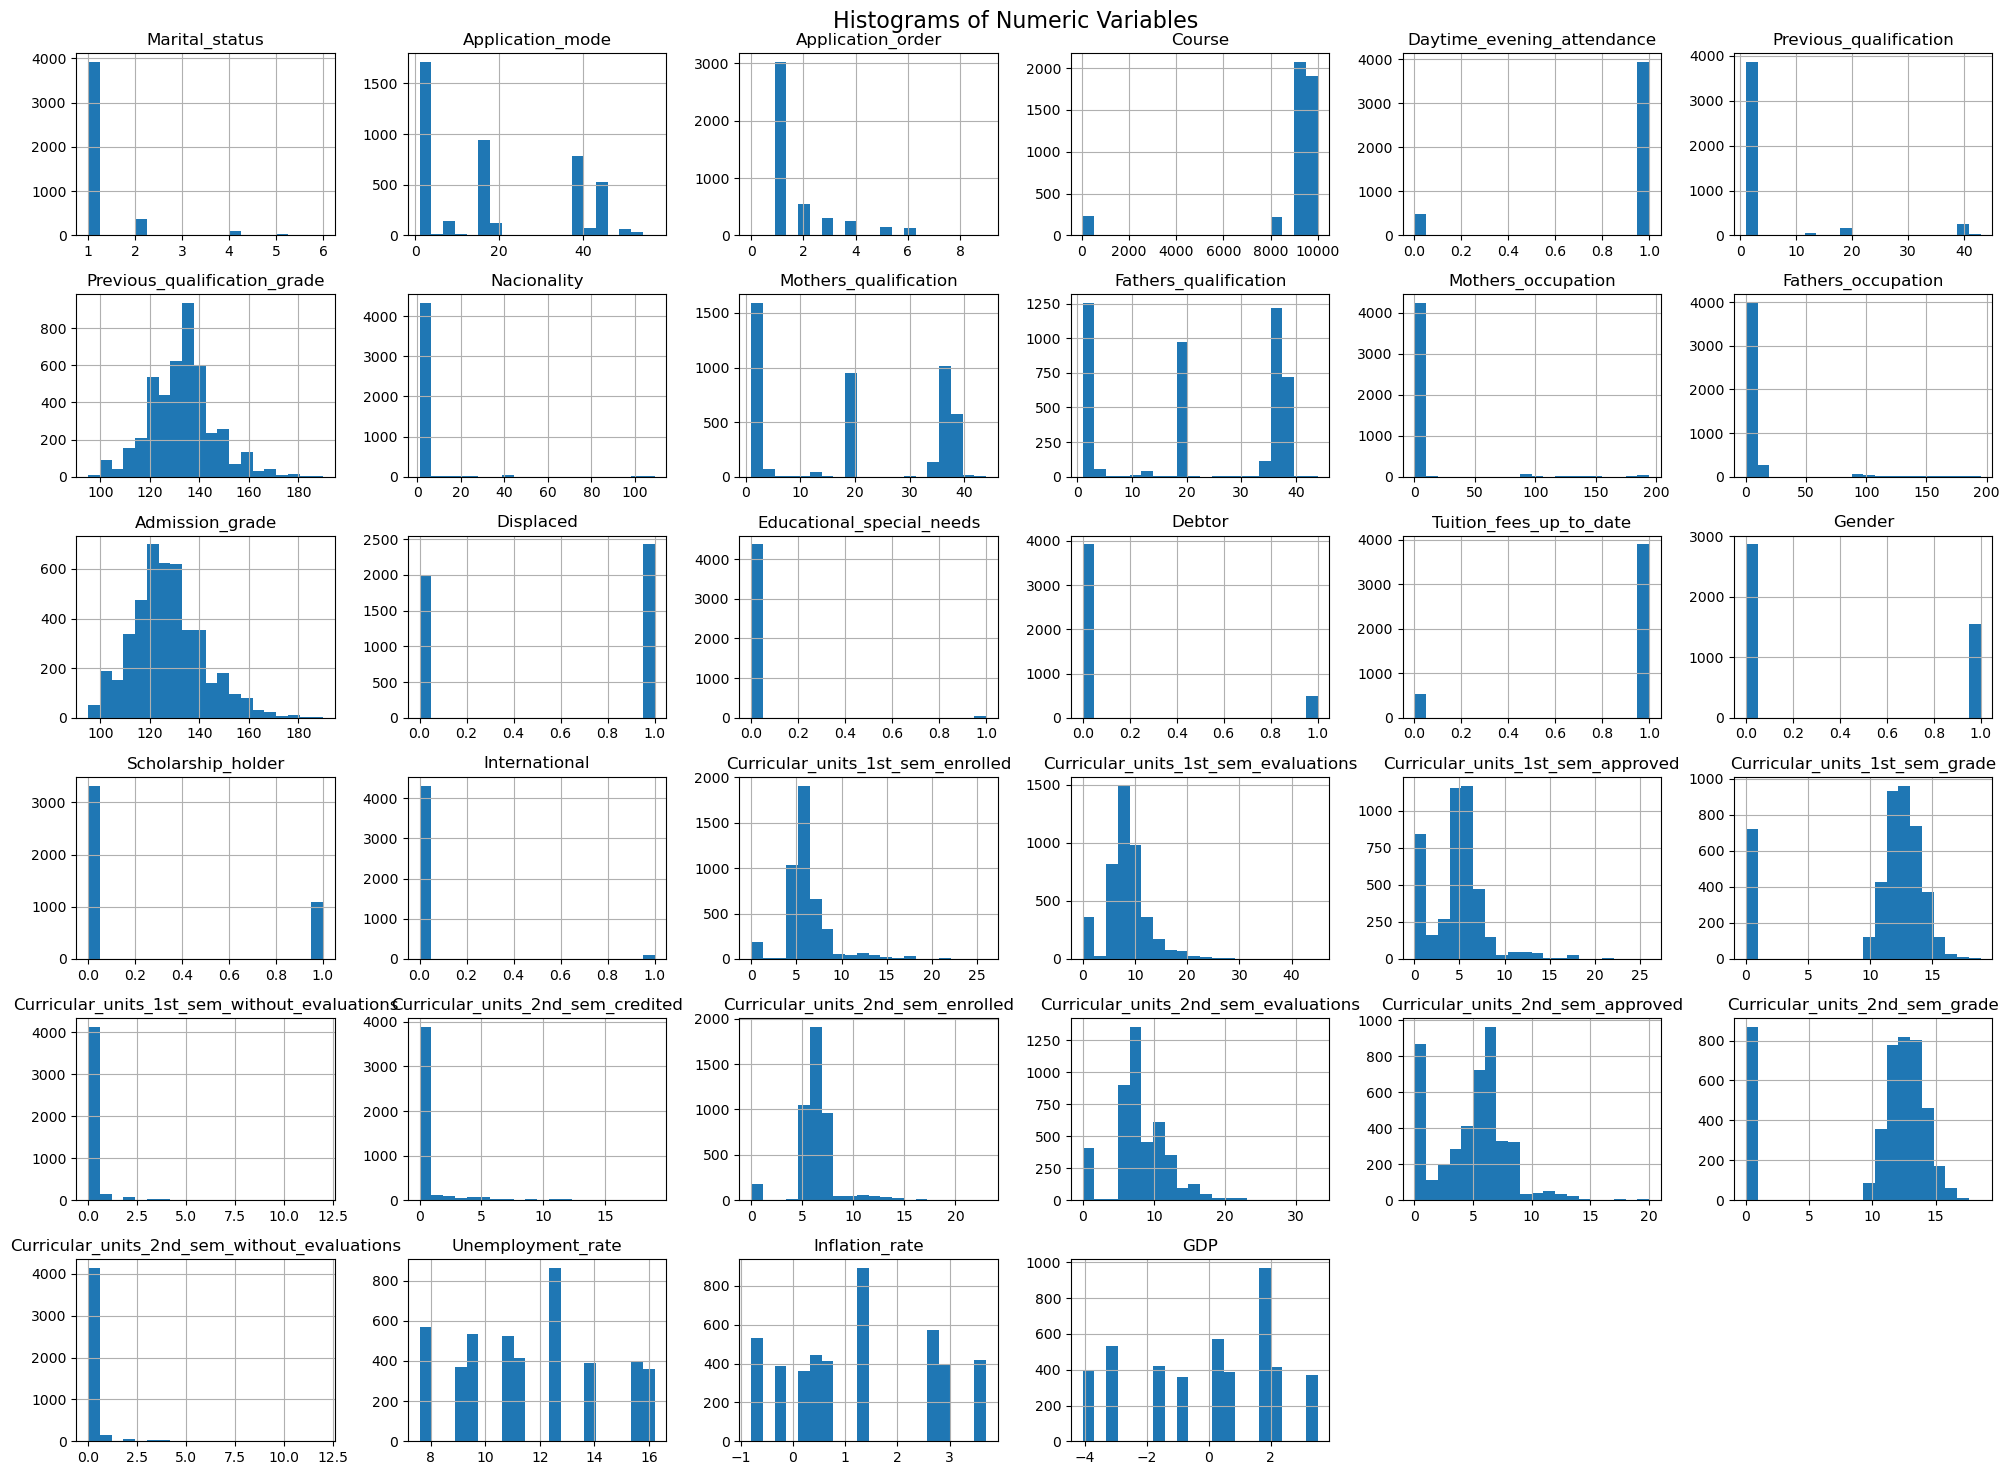

In [161]:
student_data.hist(figsize=(20,15), bins=20)
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

The histogram shows how many values ​​fit into each area. The fact that a large portion of them indicates an apparent trend or pattern in your data.

# Correlation Between Variables

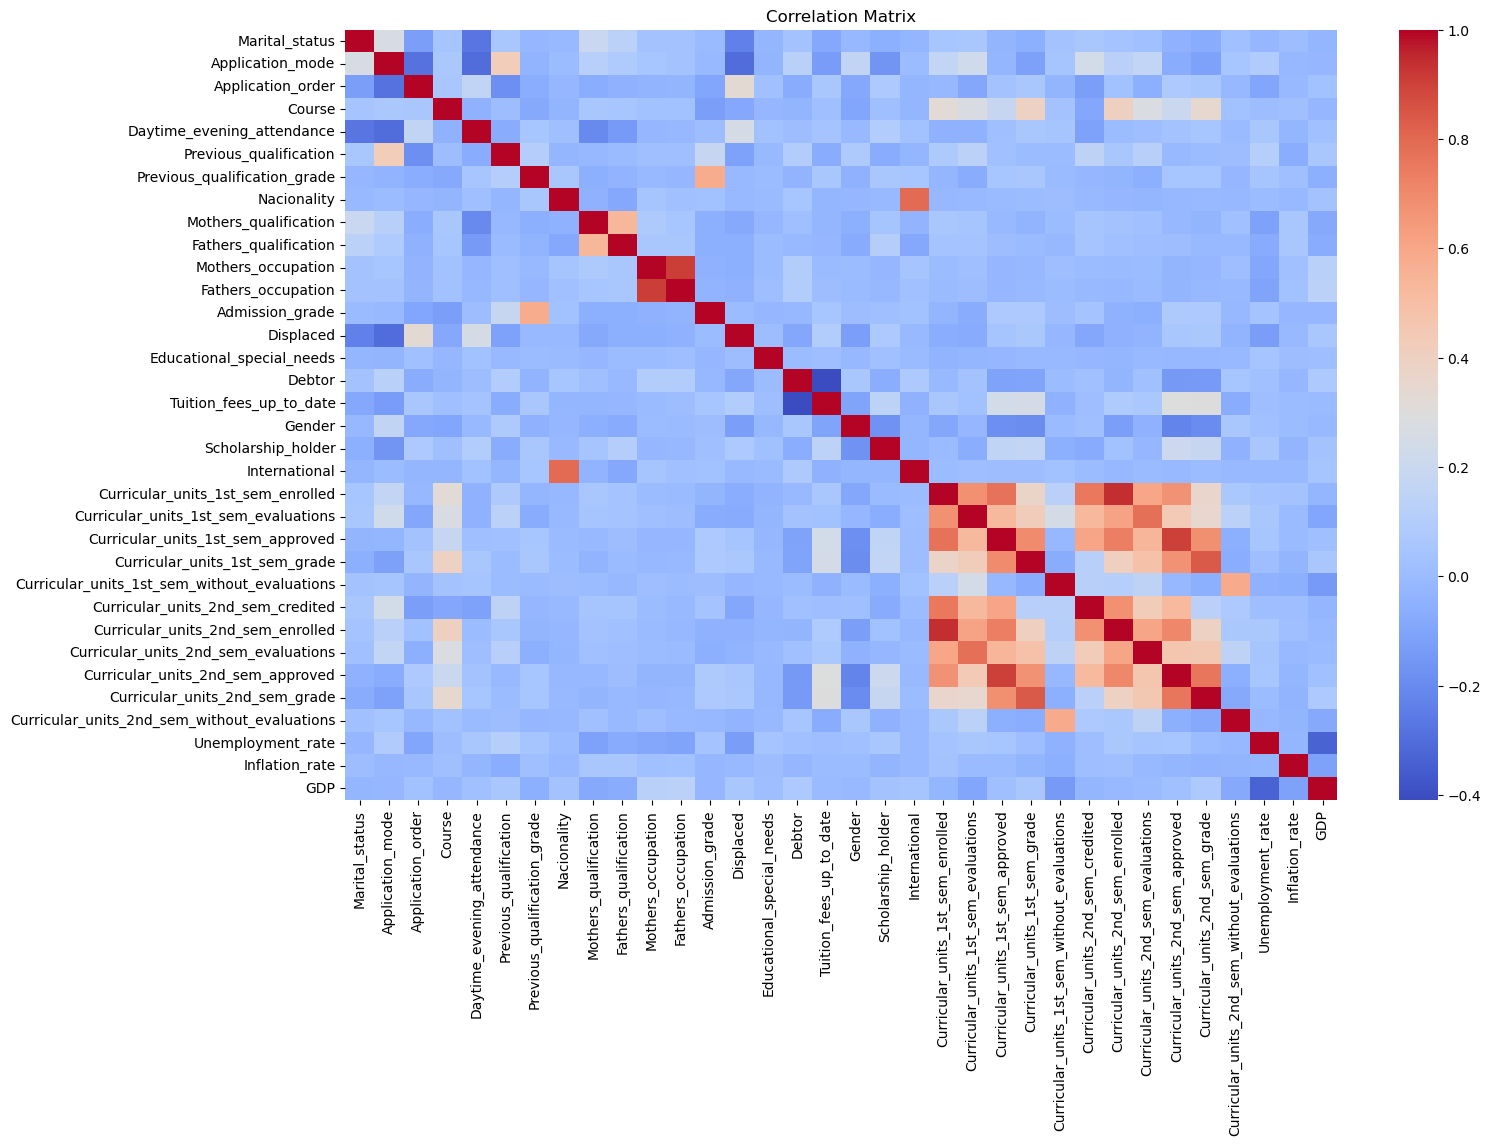

In [162]:
plt.figure(figsize=(16,10))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

The correlation heatmap shows the relationships between several variables. Some variables show a high degree of correlation, which may indicate redundancy and supports the use of dimensionality reduction techniques such as PCA.

# Outlier Detection (Boxplot)

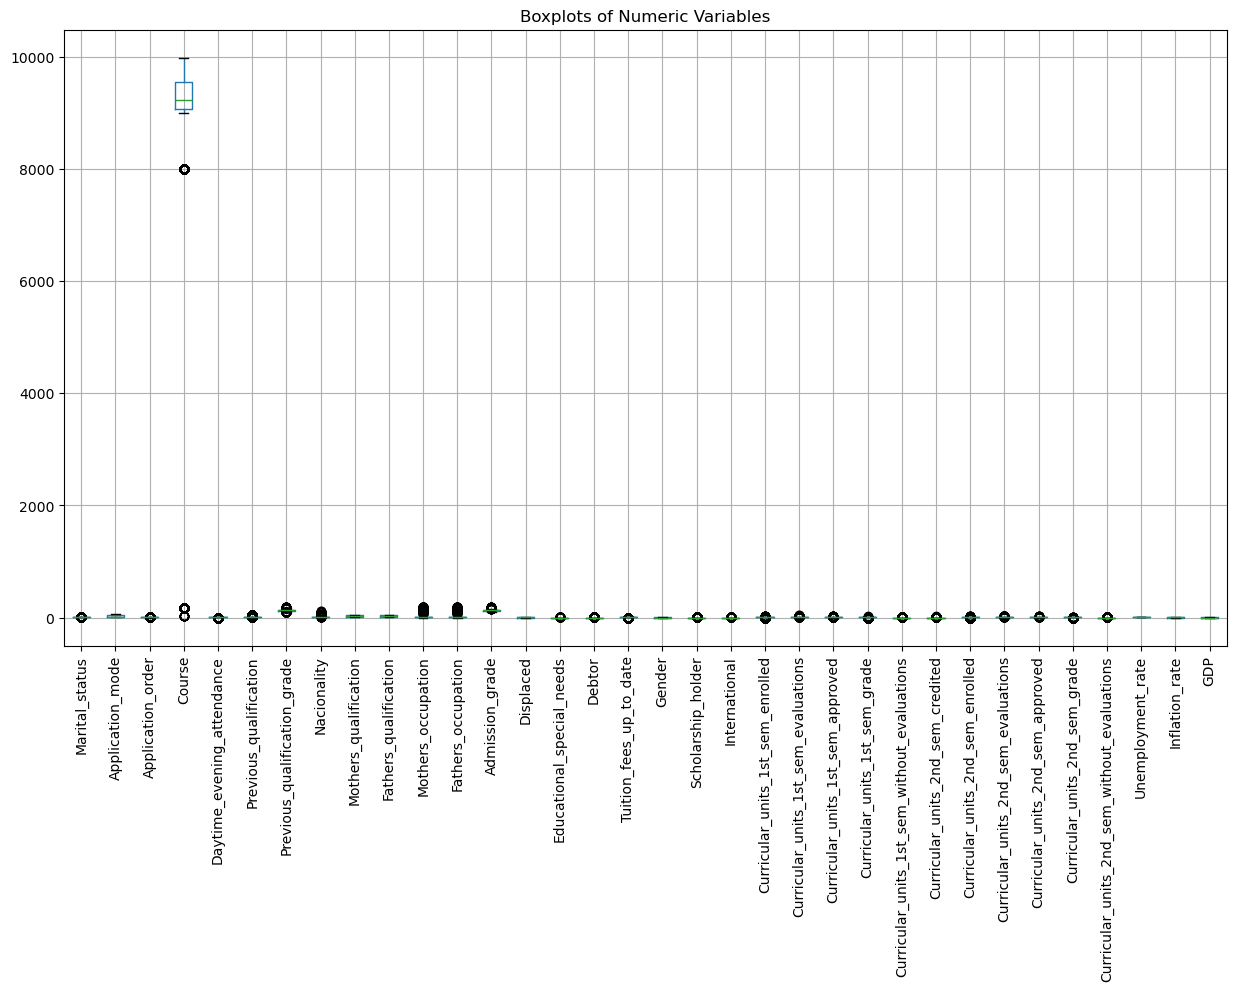

In [163]:
plt.figure(figsize=(15,8))
student_data.select_dtypes(include=np.number).boxplot(rot=90)
plt.title("Boxplots of Numeric Variables")
plt.show()

Boxplot The boxplot points to the existence of outliers. These could potentially have an impact on your analysis so you need to take these into consideration when assessing the implications of your research.

In [164]:
student_data = student_data.dropna()

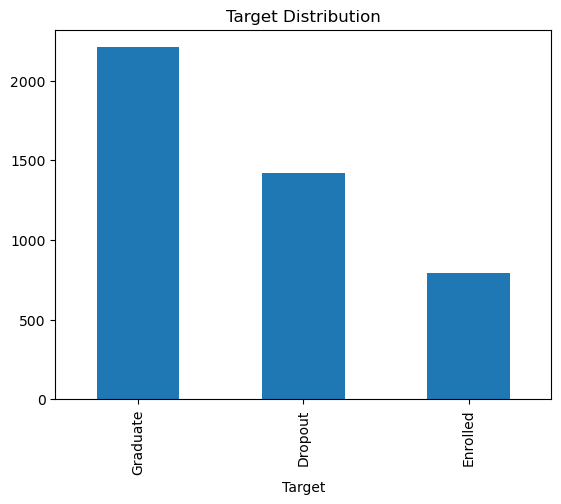

In [165]:
student_data["Target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

One class clearly shows a higher frequency than all others. In terms of evaluating the predictive ability of your model, the above situation may require a more detailed analysis.

In [166]:
from sklearn.decomposition import PCA
from sklearn import model_selection

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [167]:
student_data["Target"] = student_data["Target"].astype(str).str.strip().str.lower()

student_data["Target"] = student_data["Target"].map({
    "dropout": 0,
    "enrolled": 1,
    "graduate": 2
})

student_data["Target"].value_counts()

Target
2    2209
0    1421
1     794
Name: count, dtype: int64

In [168]:
features = student_data.drop("Target", axis=1)
target = student_data["Target"]

In [169]:
features = pd.get_dummies(features)
features.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_credited_2,Curricular_units_1st_sem_credited_20,Curricular_units_1st_sem_credited_3,Curricular_units_1st_sem_credited_4,Curricular_units_1st_sem_credited_5,Curricular_units_1st_sem_credited_6,Curricular_units_1st_sem_credited_7,Curricular_units_1st_sem_credited_8,Curricular_units_1st_sem_credited_9,Curricular_units_1st_sem_credited_Na
0,1.0,17,5,171.0,1,1,122.0,1,19,12.0,...,False,False,False,False,False,False,False,False,False,False
1,1.0,15,1,9254.0,1,1,160.0,1,1,3.0,...,False,False,False,False,False,False,False,False,False,False
2,1.0,1,5,9070.0,1,1,122.0,1,37,37.0,...,False,False,False,False,False,False,False,False,False,False
3,1.0,17,2,9773.0,1,1,122.0,1,38,37.0,...,False,False,False,False,False,False,False,False,False,False
4,2.0,39,1,8014.0,0,1,100.0,1,37,38.0,...,False,False,False,False,False,False,False,False,False,False


# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was performed to reduce the dimensionality of the dataset, as exploratory analysis suggested that some variables might contain overlapping information. By grouping the original features into a smaller number of components, it is possible to simplify the dataset while maintaining much of the underlying structure.

The 99.5% variance retention demonstrates that almost all the information contained in the original dataset is preserved in the reduced version. However, this flow also reveals a disadvantage, as the new components are less interpretable than the original variables. In this case, PCA was used to balance simplicity and information retention, aiming to improve the quality of the modeling process.

In [170]:
pca = PCA()
projected = pca.fit_transform(features)

In [171]:
print(pca.explained_variance_ratio_)

[9.99349231e-01 3.00274310e-04 9.12334577e-05 7.52409487e-05
 6.85806914e-05 2.63738198e-05 1.96688397e-05 1.67468212e-05
 1.46844766e-05 1.38121979e-05 1.08865829e-05 4.42851133e-06
 2.13501352e-06 1.89437923e-06 9.81365729e-07 9.20827437e-07
 7.26825672e-07 4.35601530e-07 3.71635387e-07 2.53177391e-07
 1.97401017e-07 1.74325792e-07 1.57499133e-07 8.16701816e-08
 5.34163660e-08 4.99711825e-08 4.57032446e-08 4.29267550e-08
 3.80878691e-08 3.68017845e-08 3.44893180e-08 2.95398607e-08
 1.91641501e-08 1.79133472e-08 1.35821072e-08 1.28862238e-08
 1.06016242e-08 7.15912539e-09 6.24837365e-09 5.16950412e-09
 4.96907187e-09 4.82860217e-09 4.53517296e-09 4.34516207e-09
 3.79064138e-09 3.52214391e-09 3.22874435e-09 3.14778355e-09
 2.93651804e-09 2.72929228e-09 2.69713031e-09 2.63450426e-09
 2.49073849e-09 2.42667426e-09 2.40076123e-09 2.22359091e-09
 2.15499334e-09 2.11172192e-09 1.99506770e-09 1.96676413e-09
 1.88114920e-09 1.65175768e-09 1.53672851e-09 1.52403161e-09
 1.36713922e-09 1.320338

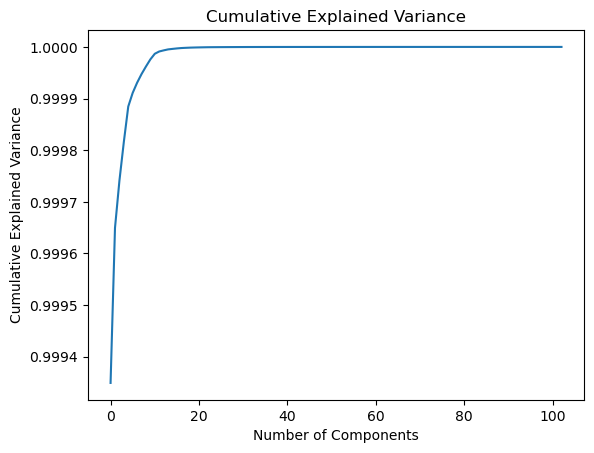

In [172]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

# Curse of Dimensionality

The "curse of dimensionality" is an expression used to describe the problems encountered in processing datasets with many attributes (or columns). As the number of attributes increases, the dispersion of the dataset also increases; therefore, the ability of machine learning algorithms to find meaningful relationships between the various characteristics of the data decreases. Furthermore, with the increasing number of attributes, distance-based approaches become less reliable, since the value differences between different attributes lose significance in high-dimensional spaces.

This same problem occurs in our specific dataset during/after data preparation, especially when categorical attributes are converted into numerical representations. However, the number of dimensions in the dataset grows along with redundant information. By using Principal Component Analysis (PCA) to reduce the number of attributes in a dataset while maintaining as much variance as possible, we can make the dataset easier to work with and improve its predictive potential.

# Model Testing and Evaluation

The results of the principal component analysis (PCA) were then evaluated with classification models to confirm whether data reduction would bring advantages or disadvantages. The main objective was to assess the performance of each model using the original dataset versus the new reduced dataset.

Testing the new dataset is crucial because preserving variance does not always translate into greater predictive accuracy. Testing the new dataset will allow us to have a more realistic assessment of whether PCA contributes positively to our modeling processes in this specific case.

In [173]:
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.995) + 1
n_components

np.int64(1)

In [174]:
pca = PCA(n_components=n_components)
projected = pca.fit_transform(features)

In [175]:
projected.shape

(4424, 1)

In [176]:
student_pca = pd.DataFrame(projected)
student_pca.head()

,0
0,-8685.562896
1,397.407613
2,213.433060
3,916.477537
4,-842.512343


In [177]:
student_pca["Target"] = target.values
student_pca.head()

,0,Target
0,-8685.562896,0
1,397.407613,2
2,213.433060,0
3,916.477537,2
4,-842.512343,2


In [178]:
array = student_pca.values
array

array([[-8.68556290e+03,  0.00000000e+00],
       [ 3.97407613e+02,  2.00000000e+00],
       [ 2.13433060e+02,  0.00000000e+00],
       ...,
       [ 6.43431950e+02,  0.00000000e+00],
       [ 2.90405968e+02,  2.00000000e+00],
       [ 9.16426575e+02,  2.00000000e+00]], shape=(4424, 2))

In [179]:
features = array[:, 0:n_components]
target = array[:, n_components]

In [180]:
features_train, features_validation, target_train, target_validation = model_selection.train_test_split(
    features, target, test_size=0.20, random_state=1
)

In [181]:
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

In [182]:
results = []
names = []

for name, model in models:
    kfold = model_selection.StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = model_selection.cross_val_score(model, features_train, target_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

C:\Users\peric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\peric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
C:\Users\peric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\peric\anaconda3\Lib\site

LR: 0.498728 (0.001333)
LDA: 0.498728 (0.001333)
KNN: 0.481783 (0.033514)
CART: 0.445612 (0.030044)
NB: 0.495058 (0.011217)
SVM: 0.543373 (0.015904)


# Results and Discussion

The results show differences in the performance of various machine learning models when using the complete (original) dataset compared to the reduced dataset. Although, in some cases, the reduced dataset performed similarly to the original, due to the successful use of Principal Component Analysis (PCA) to remove redundant information without affecting accuracy, the slightly lower performance shown by some models indicates that some potentially useful information may have been lost from the original dataset during the dimensionality reduction process. The results show a clear relationship between the reduction in dataset complexity and the impact on the model's ability to make accurate predictions.

## Final Considerations

In this research project, we used a student dataset, cleaning and analyzing the data to understand the distribution of variables. Then, we performed Principal Component Analysis (PCA) to reduce the number of variables, minimizing variance. This work taught us to understand the structure and quality of the original dataset, exploring the relationships between variables and identifying patterns in their distribution.

The use of PCA to analyze the data demonstrated the advantage of reducing the number of variables when dealing with large volumes of data. Although PCA offers advantages such as simplifying the size and complexity of the dataset, it can sometimes hinder the understanding of the meaning of the components and, in rare cases, negatively impact the model's performance.

In conclusion, the study demonstrates that PCA can be an excellent tool to assist in the management of more complex and high-dimensional data. However, before using PCA, it is essential to verify if it actually produces good results.